# MPC implementation with TEP datasets
description here

Load data using `pyreadr`

In [2]:
import pyreadr

training_data = pyreadr.read_r('./datasets/tep/TEP_FaultFree_Training.RData')
print(training_data.keys())

odict_keys(['fault_free_training'])


In [3]:
import pandas as pd

train_df = pd.DataFrame(training_data['fault_free_training'])

Verify that dataset is loaded correctly

In [4]:
print(train_df.shape)
print(train_df.columns)
train_df.head()

(250000, 55)
Index(['faultNumber', 'simulationRun', 'sample', 'xmeas_1', 'xmeas_2',
       'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8',
       'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14',
       'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20',
       'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_24', 'xmeas_25', 'xmeas_26',
       'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_30', 'xmeas_31', 'xmeas_32',
       'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmeas_37', 'xmeas_38',
       'xmeas_39', 'xmeas_40', 'xmeas_41', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4',
       'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11'],
      dtype='str')


,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


Check if data needs to be cleaned

In [5]:
train_df.isnull().sum()

faultNumber      0
simulationRun    0
sample           0
xmeas_1          0
xmeas_2          0
xmeas_3          0
xmeas_4          0
xmeas_5          0
xmeas_6          0
xmeas_7          0
xmeas_8          0
xmeas_9          0
xmeas_10         0
xmeas_11         0
xmeas_12         0
xmeas_13         0
xmeas_14         0
xmeas_15         0
xmeas_16         0
xmeas_17         0
xmeas_18         0
xmeas_19         0
xmeas_20         0
xmeas_21         0
xmeas_22         0
xmeas_23         0
xmeas_24         0
xmeas_25         0
xmeas_26         0
xmeas_27         0
xmeas_28         0
xmeas_29         0
xmeas_30         0
xmeas_31         0
xmeas_32         0
xmeas_33         0
xmeas_34         0
xmeas_35         0
xmeas_36         0
xmeas_37         0
xmeas_38         0
xmeas_39         0
xmeas_40         0
xmeas_41         0
xmv_1            0
xmv_2            0
xmv_3            0
xmv_4            0
xmv_5            0
xmv_6            0
xmv_7            0
xmv_8            0
xmv_9       

In [6]:
from sklearn.preprocessing import StandardScaler

u_cols = [f'xmv_{i}' for i in range(1, 12)]
y_cols = [f'xmeas_{i}' for i in range(1, 42)]

U_raw = train_df[u_cols].values
Y_raw = train_df[y_cols].values

scaler_u = StandardScaler()
scaler_y = StandardScaler()

U = scaler_u.fit_transform(U_raw).T
Y = scaler_y.fit_transform(Y_raw).T

U.shape, Y.shape

((11, 250000), (41, 250000))

Create state space from TEP data

In [7]:
from sippy_unipi import system_identification

sys_id = system_identification(Y, U, 'N4SID', SS_fixed_order=20)

A = sys_id.A
B = sys_id.B
C = sys_id.C
D = sys_id.D

Check if our state space's matrices have correct shapes to solve formula below:
$$
\dot{x}(t) = Ax(t)+Bu(t) \\
\dot{y}(t) = Cx(t)+Du(t)
$$

In [8]:
A.shape, B.shape, C.shape, D.shape

((20, 20), (20, 11), (41, 20), (41, 11))

In [9]:
D.max()

np.float64(0.0)

c:\Users\borys\OneDrive\Documents\Projects\python\hurtownie_danych\prediction-time-series\.venv\Lib\site-packages\control\timeresp.py:1196: RuntimeWarning: overflow encountered in matmul
  xout[:, i] = (Ad @ xout[:, i-1]
c:\Users\borys\OneDrive\Documents\Projects\python\hurtownie_danych\prediction-time-series\.venv\Lib\site-packages\control\timeresp.py:1196: RuntimeWarning: invalid value encountered in matmul
  xout[:, i] = (Ad @ xout[:, i-1]
c:\Users\borys\OneDrive\Documents\Projects\python\hurtownie_danych\prediction-time-series\.venv\Lib\site-packages\control\timeresp.py:1198: RuntimeWarning: overflow encountered in matmul
  yout = C @ xout + D @ U
c:\Users\borys\OneDrive\Documents\Projects\python\hurtownie_danych\prediction-time-series\.venv\Lib\site-packages\control\timeresp.py:1198: RuntimeWarning: invalid value encountered in matmul
  yout = C @ xout + D @ U


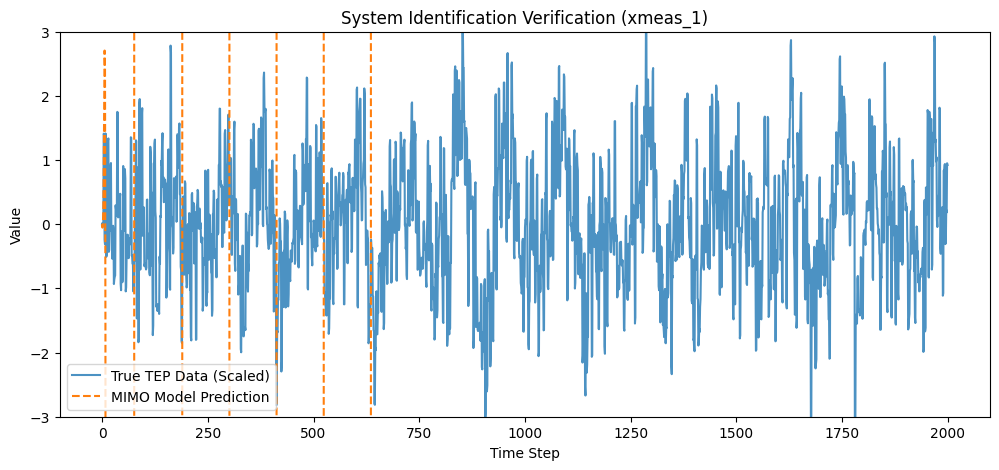

In [10]:
import control
import matplotlib.pyplot as plt
import numpy as np

T = np.arange(U.shape[1])
ss = control.StateSpace(A, B, C, D)
t, y_pred, x_hist = control.forced_response(ss, T=T, U=U, return_x=True)

time_steps = 2000
plt.figure(figsize=(12, 5))
plt.ylim(-3, 3)
plt.plot(Y[0, :time_steps], label='True TEP Data (Scaled)', alpha=0.8)
plt.plot(y_pred[0, :time_steps], label='MIMO Model Prediction', linestyle='--')
plt.title('System Identification Verification (xmeas_1)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()

Implement steady-state Kalman filter

Kalman Gain matrix shape: (20, 41)


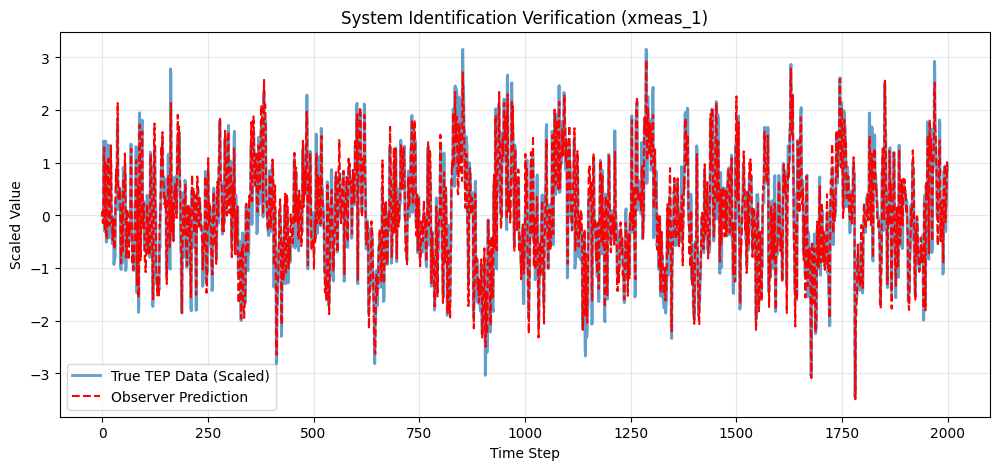

In [11]:
n_states = A.shape[0]
n_outputs = C.shape[0]
n_steps = U.shape[1]

x_hat = np.zeros((n_states, 1))
y_pred = np.zeros((n_outputs, n_steps))

# Get Kalman Gain matrix from sippy
K = getattr(sys_id, 'K', np.zeros((n_states, n_outputs)))

print(f"Kalman Gain matrix shape: {K.shape}")

for k in range(n_steps):
    u_k = U[:, k].reshape(-1, 1)
    y_k_true = Y[:, k].reshape(-1, 1)
    
    y_hat_k = C @ x_hat + D @ u_k
    y_pred[:, k] = y_hat_k.flatten()
    
    error = y_k_true - y_hat_k
    
    x_hat = A @ x_hat + B @ u_k + K @ error

plt.figure(figsize=(12, 5))

plt.plot(Y[0, :time_steps], label='True TEP Data (Scaled)', alpha=0.7, linewidth=2)
plt.plot(y_pred[0, :time_steps], label='Observer Prediction', linestyle='--', color='red')

plt.title('System Identification Verification (xmeas_1)')
plt.xlabel('Time Step')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Build a simulator

In [12]:
import do_mpc

model = do_mpc.model.Model('discrete')

x = model.set_variable(var_type='_x', var_name='x', shape=(n_states, 1))
u = model.set_variable(var_type='_u', var_name='u', shape=(U.shape[0], 1))

x_next = A @ x + B @ u
y = C @ x + D @ u

model.set_rhs('x', x_next)
model.set_expression('y', y)

model.setup()

c:\Users\borys\OneDrive\Documents\Projects\python\hurtownie_danych\prediction-time-series\.venv\Lib\site-packages\do_mpc\sysid\__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
c:\Users\borys\OneDrive\Documents\Projects\python\hurtownie_danych\prediction-time-series\.venv\Lib\site-packages\do_mpc\opcua\__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')
c:\Users\borys\OneDrive\Documents\Projects\python\hurtownie_danych\prediction-time-series\.venv\Lib\site-packages\do_mpc\approximateMPC\__init__.py:13: UserWarning: The approximateMPC feature requires PyTorch, which is not installed by default.

In [ ]:
mpc = do_mpc.controller.MPC(model)

setup_mpc = {
    'n_horizon': 20,
    't_step': 1,
    'n_robust': 0,
    'store_full_solution': True,
}
mpc.set_param(**setup_mpc)

Q = np.eye(41) * 1.0  
R = np.eye(11) * 0.1

mterm = model.aux['y'].T @ Q @ model.aux['y']
lterm = model.aux['y'].T @ Q @ model.aux['y']

mpc.set_objective(mterm=mterm, lterm=lterm)
mpc.set_rterm(u=0.1)

mpc.setup()

In [14]:
estimator = do_mpc.estimator.StateFeedback(model)
simulator = do_mpc.simulator.Simulator(model)
simulator.set_param(t_step = 1.0)
simulator.setup()

x0 = np.zeros((20, 1))

x0[0:5, 0] = 5.0 # disturbance in the first 5 states

mpc.x0 = x0
simulator.x0 = x0
estimator.x0 = x0
mpc.set_initial_guess()

# Run the control loop for 100 steps
for k in range(100):
    u0 = mpc.make_step(x0)
    y_meas = simulator.make_step(u0)
    x0 = estimator.make_step(y_meas)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:    12820
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     4839

Total number of variables............................:      640
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      420
Total number of inequality c

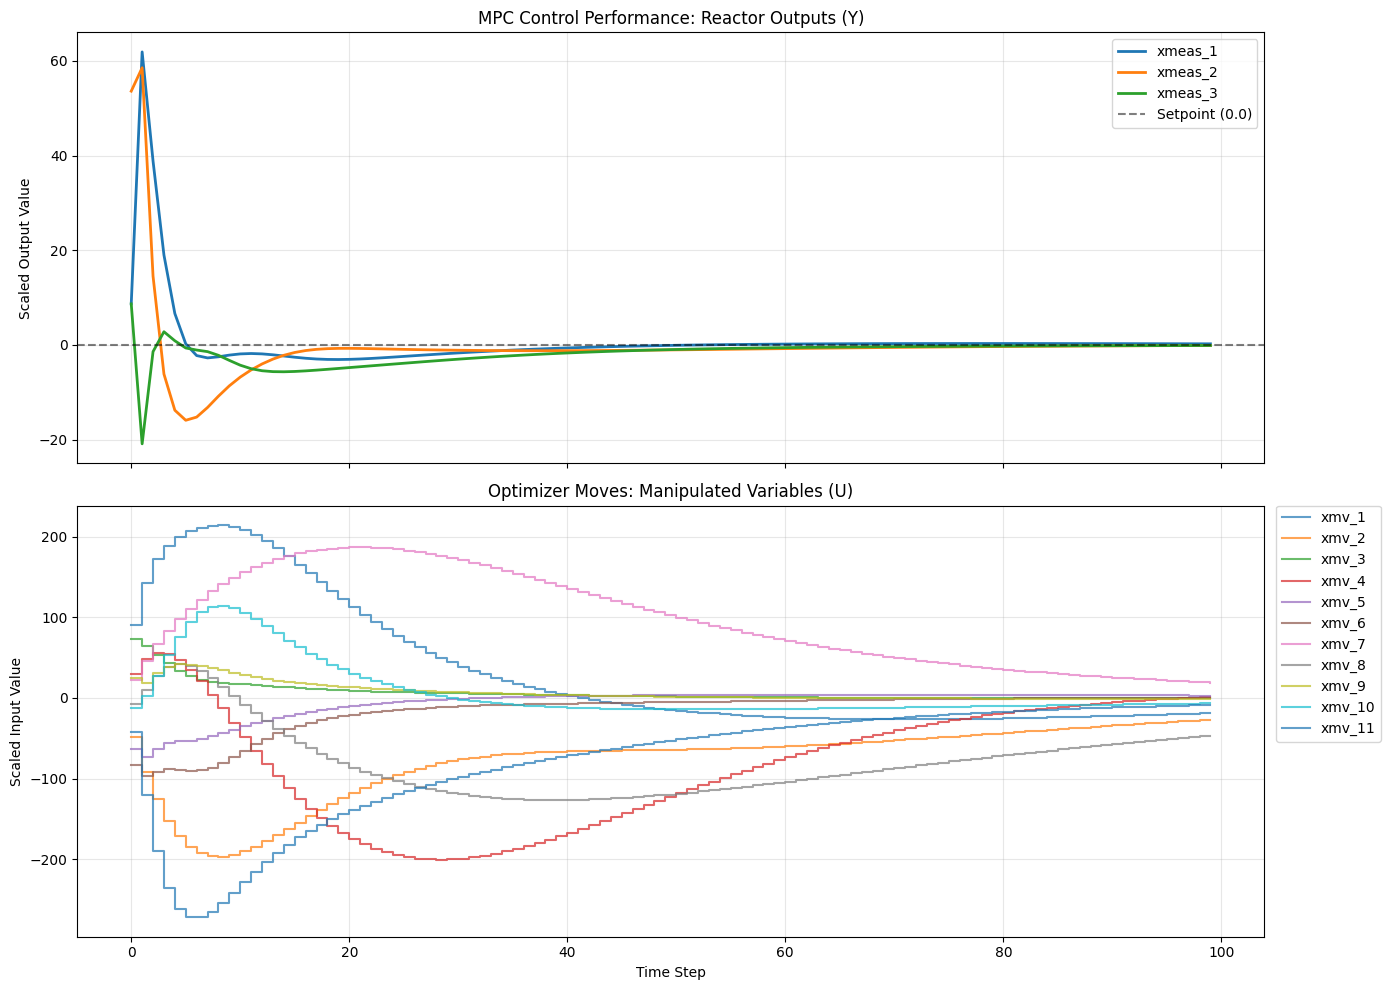

In [ ]:
# closed-loop data
time = simulator.data['_time'].flatten()
u_data = simulator.data['_u'] 
y_data = simulator.data['_aux', 'y'] 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(time, y_data[:, 0], label='xmeas_1', linewidth=2)
ax1.plot(time, y_data[:, 1], label='xmeas_2', linewidth=2)
ax1.plot(time, y_data[:, 2], label='xmeas_3', linewidth=2)

ax1.set_title('MPC Control Performance: Reactor Outputs (Y)')
ax1.set_ylabel('Scaled Output Value')
ax1.axhline(0, color='black', linestyle='--', alpha=0.5, label='Setpoint (0.0)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

for i in range(11):
    ax2.step(time, u_data[:, i], where='post', label=f'xmv_{i+1}', alpha=0.7)

ax2.set_title('Optimizer Moves: Manipulated Variables (U)')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Scaled Input Value')

ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0.)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()